In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Neural Networks - Deep Learning
**Theodora Tzina - AEM: 10715**
### Exercise 3
#### ***Part A: Autoencoder – Simple Reconstruction***

This notebook implements various autoencoder architectures for MNIST digit reconstruction and compares them with PCA. A simple CNN digit classifier is applied to reconstructed images.

In [ ]:
import numpy as np
import time
import tensorflow as tf
from keras import layers, Model
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Reshape, Flatten, BatchNormalization
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import dataProccessing as dp

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [26]:
import importlib
importlib.reload(dp)

<module 'dataProccessing' from 'c:\\Users\\theod\\OneDrive - Αριστοτέλειο Πανεπιστήμιο Θεσσαλονίκης\\Επιφάνεια εργασίας\\9ο εξάμηνο\\Νευρωνικά Δίκτυα\\Εργασίες\\Neural-Networks\\Exercise_3\\dataProccessing.py'>

**MNIST dataset preparation**

In [18]:
# Load and normalize MNIST dataset
x_train, y_train, x_test, y_test = dp.load_mnist()

# Flatten MNIST images
x_train, x_test = dp.flatten_mnist(x_train, x_test)

# Load MNIST classes
mnist_classes = dp.get_class_names()

# Get one example of each digit from the test set
test_indices = dp.get_stratified_samples(y_test, n_per_class=1)
test_samples = x_test[test_indices]

Loading and Normalizing MNIST Dataset
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

Flattening MNIST images
Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)

MNIST Classes
0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6
7: 7
8: 8
9: 9



#### **Model 1: Simple Dense Autoencoder**
A basic autoencoder with few Dense layers and small encoding dimension.


Training Model 1...

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0723 - val_loss: 0.0431
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0353 - val_loss: 0.0294
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0249 - val_loss: 0.0222
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0203 - val_loss: 0.0193
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0181 - val_loss: 0.0177
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0167 - val_loss: 0.0165
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0157 - val_loss: 0.0156
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0149 - val_loss: 0.0148
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0142 - val_loss: 0.0143
Epoch 10/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0137 - val_loss: 0.0139
Epoch 11/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0133 - val_loss: 0.0135
Epoch 12/50
141/141 ━━━━━━━━━━

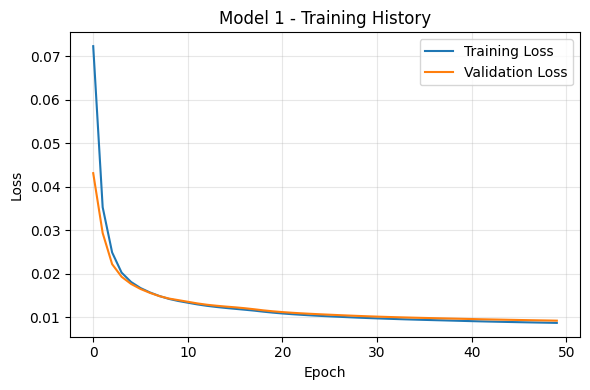

Model 1 Final Validation Loss: 0.009206
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


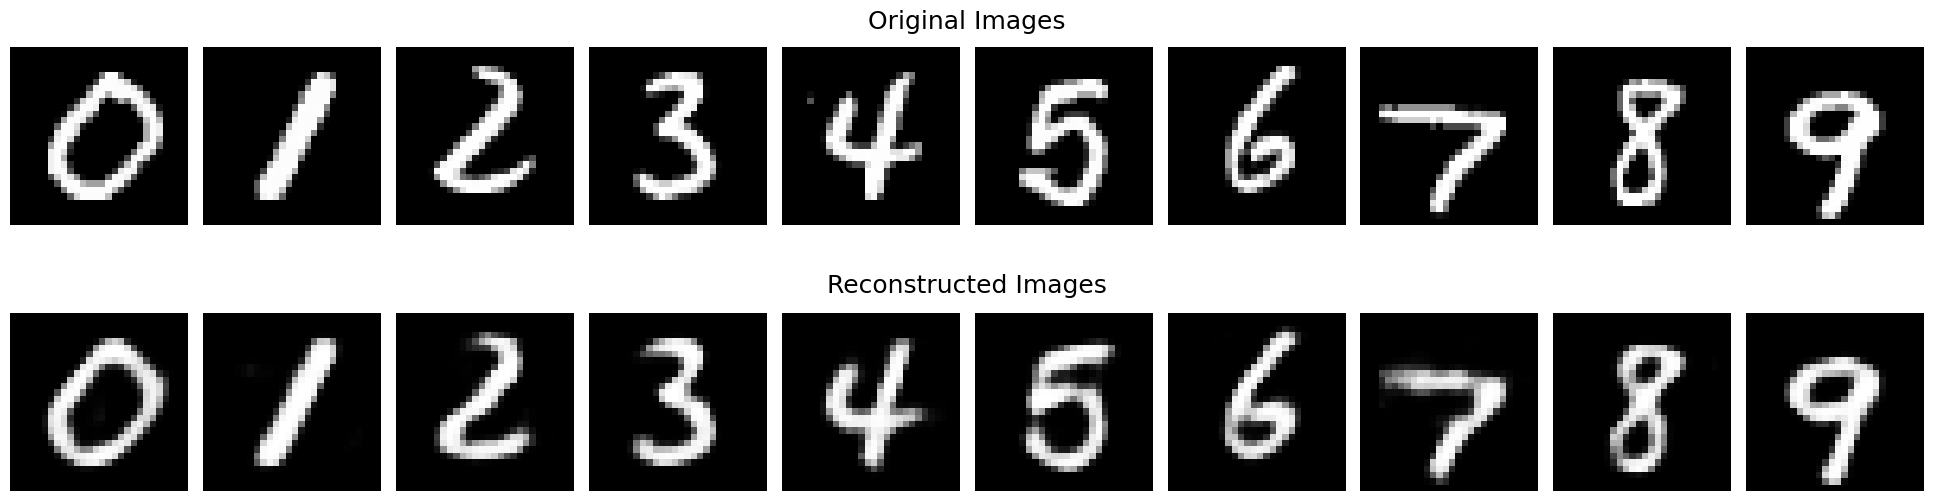

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Model 1 Test MSE: 0.008717


In [19]:
# Model 1: Simple Autoencoder with small encoding
encoding_dim = 32

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(128, activation='relu')(encoder_input)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_1 = Model(encoder_input, latent, name='encoder_1')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_1 = Model(decoder_input, decoder_output, name='decoder_1')

# Autoencoder Model
autoencoder_1 = Model(encoder_input, decoder_1(encoder_1(encoder_input)), name='autoencoder_1')
autoencoder_1.compile(optimizer='adam', loss='mse')

# Train the model
print("\nTraining Model 1...\n")
start_time = time.time()
history_1 = autoencoder_1.fit(x_train, x_train, epochs=50,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_1 = time.time() - start_time
print(f"\nModel 1 Training Time: {train_time_1:.2f} seconds")

# Plot training history
dp.plot_history(history_1, "Model 1")

# Store validation loss
val_loss_1 = history_1.history['val_loss'][-1]
print(f"Model 1 Final Validation Loss: {val_loss_1:.6f}")

# Visualize reconstructions on test set
reconstructed_1 = autoencoder_1.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_1, n=10)

# Calculate test MSE loss
mse_1 = dp.calculate_mse(x_test, autoencoder_1.predict(x_test))
print(f"Model 1 Test MSE: {mse_1:.6f}")

#### **Model 2: Deeper Dense Autoencoder**
Adding more Dense layers and icreasing encoding dimension.


Training Model 2...

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0688 - val_loss: 0.0388
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0302 - val_loss: 0.0253
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0222 - val_loss: 0.0202
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0183 - val_loss: 0.0171
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0156 - val_loss: 0.0152
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0138 - val_loss: 0.0135
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0125 - val_loss: 0.0125
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0118 - val_loss: 0.0119
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0111 - val_loss: 0.0113
Epoch 10/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0104 - val_loss: 0.0110
Epoch 11/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0100 - val_loss: 0.0108
Epoch 12/50
141/141

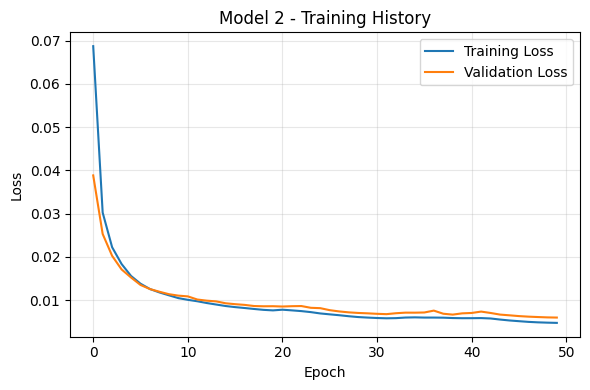

Model 2 Final Validation Loss: 0.005937
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


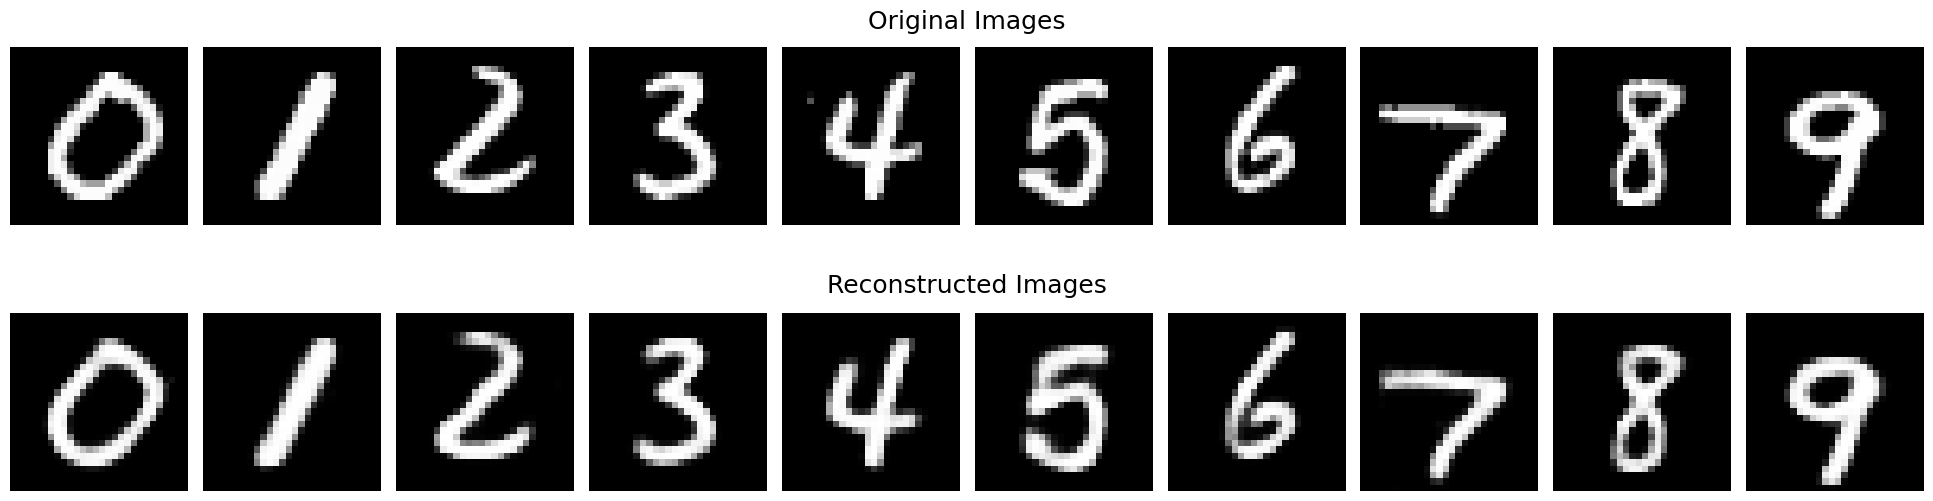

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model 2 Test MSE: 0.005673


In [20]:
# Model 2: Deeper Autoencoder with larger encoding
encoding_dim = 64

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_2 = Model(encoder_input, latent, name='encoder_2')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_2 = Model(decoder_input, decoder_output, name='decoder_2')

# Autoencoder Model
autoencoder_2 = Model(encoder_input, decoder_2(encoder_2(encoder_input)), name='autoencoder_2')
autoencoder_2.compile(optimizer='adam', loss='mse')

# Train the model
print("\nTraining Model 2...\n")
start_time = time.time()
history_2 = autoencoder_2.fit(x_train, x_train, epochs=50,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_2 = time.time() - start_time
print(f"\nModel 2 Training Time: {train_time_2:.2f} seconds")

# Plot training history
dp.plot_history(history_2, "Model 2")

# Store validation loss
val_loss_2 = history_2.history['val_loss'][-1]
print(f"Model 2 Final Validation Loss: {val_loss_2:.6f}")

# Get 

# Visualize reconstructions on test set
reconstructed_2 = autoencoder_2.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_2, n=10)

# Calculate test MSE
mse_2 = dp.calculate_mse(x_test, autoencoder_2.predict(x_test))
print(f"Model 2 Test MSE: {mse_2:.6f}")


#### **Model 3: Larger bottleneck Autoencoder**
Using the same Dense layers for even larger encoding dimension.


Training Model 3...

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0584 - val_loss: 0.0298
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0220 - val_loss: 0.0176
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0154 - val_loss: 0.0143
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0129 - val_loss: 0.0124
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0111 - val_loss: 0.0109
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0101 - val_loss: 0.0102
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0094 - val_loss: 0.0104
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0087 - val_loss: 0.0090
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0081 - val_loss: 0.0082
Epoch 10/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0075 - val_loss: 0.0077
Epoch 11/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0072 - val_loss: 0.0074
Epoch 12/50
141/141

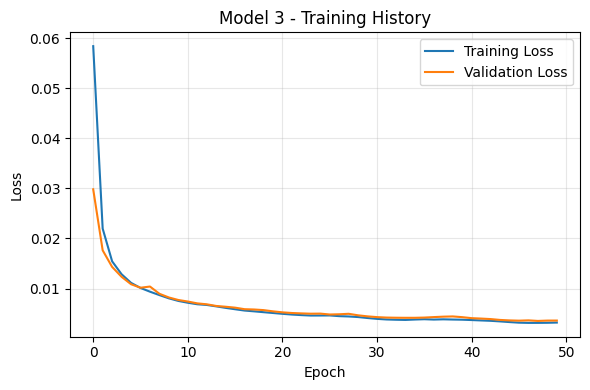

Model 3 Final Validation Loss: 0.003624
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


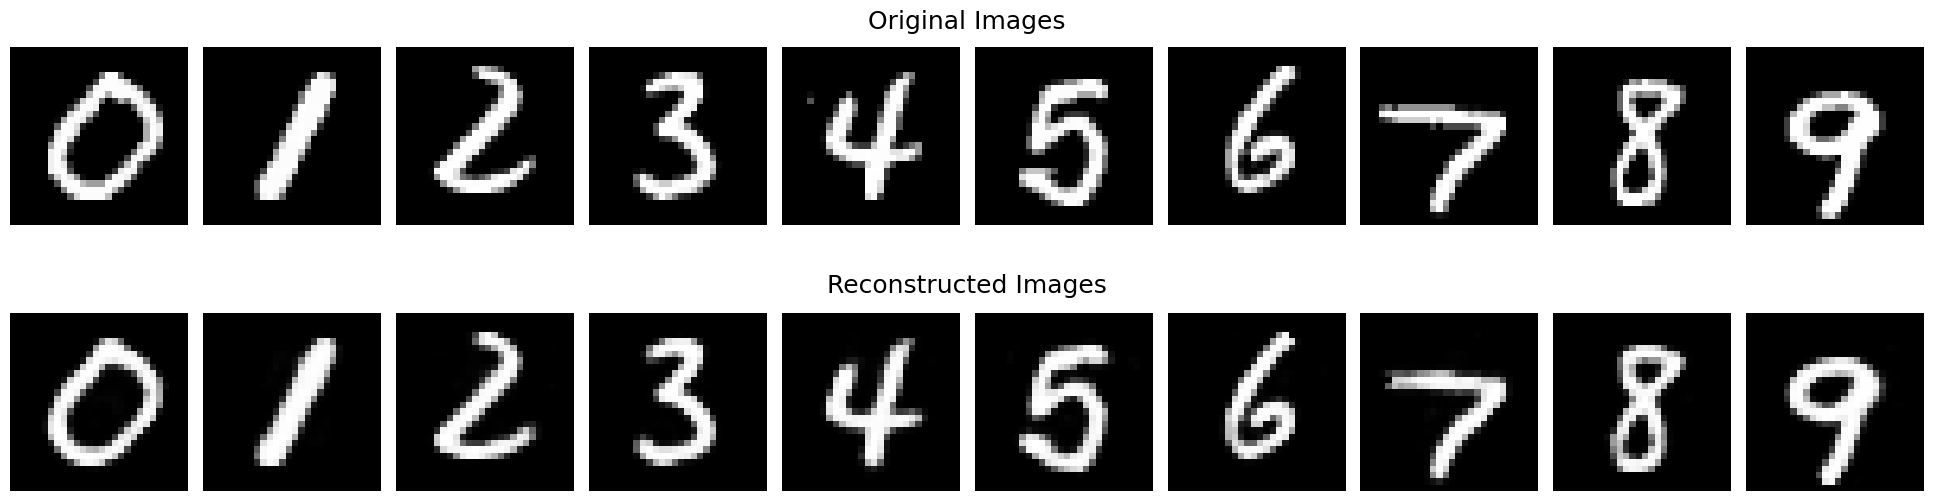

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model 3 Test MSE: 0.003439


In [21]:
# Model 3: Deeper Autoencoder with larger encoding
encoding_dim = 128

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dense(256, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_3 = Model(encoder_input, latent, name='encoder_3')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(256, activation='relu')(decoder_input)
x = layers.Dense(512, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_3 = Model(decoder_input, decoder_output, name='decoder_3')

# Autoencoder Model
autoencoder_3 = Model(encoder_input, decoder_3(encoder_3(encoder_input)), name='autoencoder_3')
autoencoder_3.compile(optimizer='adam', loss='mse')

# Train the model
print("\nTraining Model 3...\n")
start_time = time.time()
history_3 = autoencoder_3.fit(x_train, x_train, epochs=50,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_3 = time.time() - start_time
print(f"\nModel 3 Training Time: {train_time_3:.2f} seconds")

# Plot training history
dp.plot_history(history_3, "Model 3")

# Store validation loss
val_loss_3 = history_3.history['val_loss'][-1]
print(f"Model 3 Final Validation Loss: {val_loss_3:.6f}")

# Visualize reconstructions on test set
reconstructed_3 = autoencoder_3.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_3, n=10)

# Calculate test MSE
mse_3 = dp.calculate_mse(x_test, autoencoder_3.predict(x_test))
print(f"Model 3 Test MSE: {mse_3:.6f}")

#### **Model 4: Autoencoder with more metrics**

Using the same Dense layers and encoding dimension but training with more metrics.


Training Model 4...

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0584 - psnr: 13.1875 - ssim: 0.3611 - val_loss: 0.0292 - val_psnr: 15.8026 - val_ssim: 0.6099
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0215 - psnr: 17.2843 - ssim: 0.7183 - val_loss: 0.0171 - val_psnr: 18.2690 - val_ssim: 0.7849
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0146 - psnr: 19.0058 - ssim: 0.8154 - val_loss: 0.0132 - val_psnr: 19.4565 - val_ssim: 0.8409
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0120 - psnr: 19.8688 - ssim: 0.8510 - val_loss: 0.0114 - val_psnr: 20.0951 - val_ssim: 0.8620
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0104 - psnr: 20.5278 - ssim: 0.8732 - val_loss: 0.0104 - val_psnr: 20.4818 - val_ssim: 0.8766
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0094 - psnr: 20.9470 - ssim: 0.8855 - val_loss: 0.0097 - val_psnr: 20.7923 - val_ssim: 0.8733
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━

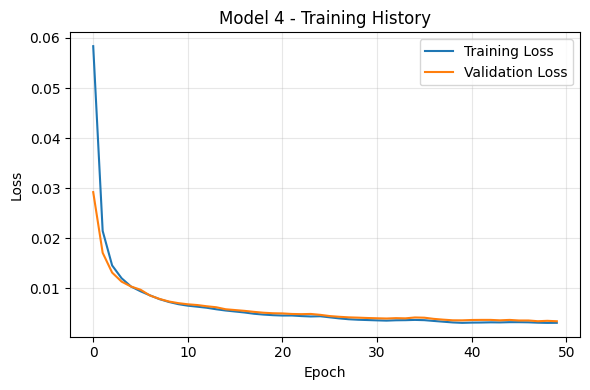

Model 4 Final Validation Loss: 0.003447
Model 4 Final Validation PSNR: 25.713749
Model 4 Final Validation SSIM: 0.958469
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


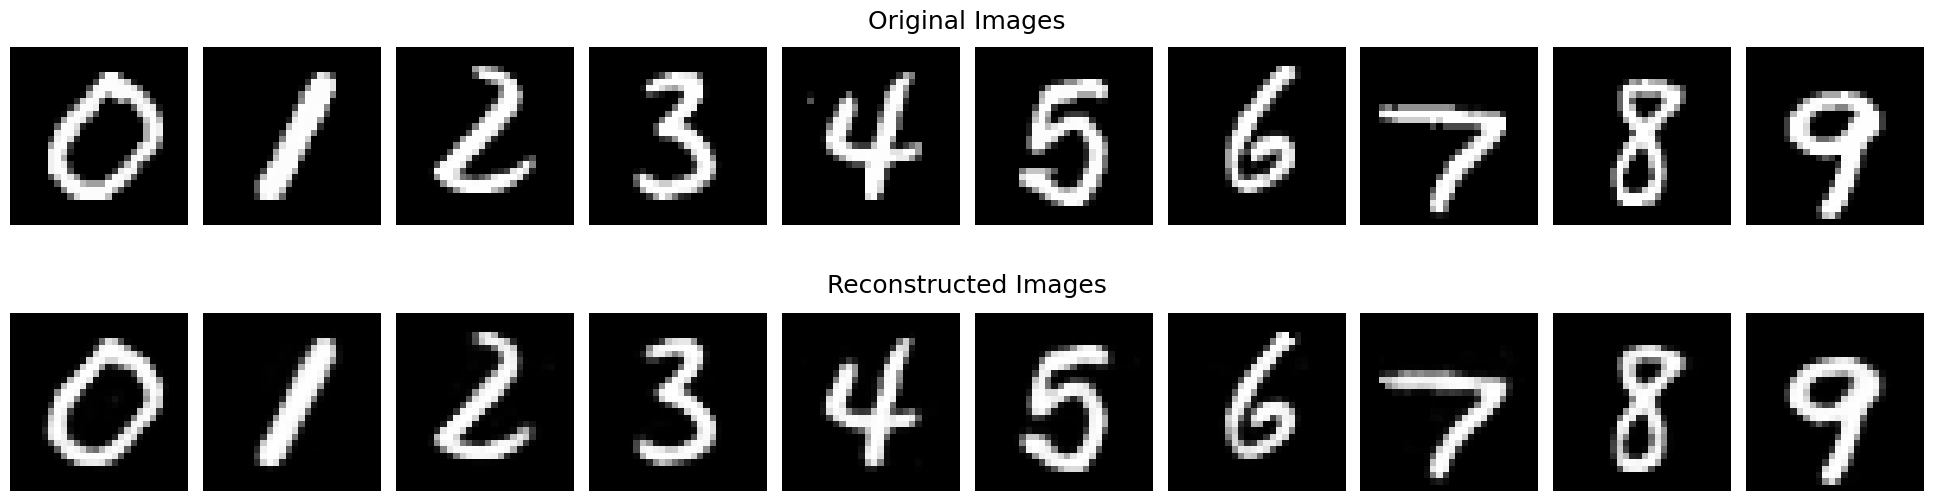

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model 4 Test MSE: 0.003265


In [22]:
# Model 4: Deeper Autoencoder with larger encoding
encoding_dim = 128

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dense(256, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_4 = Model(encoder_input, latent, name='encoder_4')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(256, activation='relu')(decoder_input)
x = layers.Dense(512, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_4 = Model(decoder_input, decoder_output, name='decoder_4')

# Autoencoder Model
autoencoder_4 = Model(encoder_input, decoder_4(encoder_4(encoder_input)), name='autoencoder_4')
autoencoder_4.compile(optimizer='adam', loss='mse', metrics=[dp.psnr, dp.ssim])

# Train the model
print("\nTraining Model 4...\n")
start_time = time.time()
history_4 = autoencoder_4.fit(x_train, x_train, epochs=50,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_4 = time.time() - start_time
print(f"\nModel 4 Training Time: {train_time_4:.2f} seconds")

# Plot training history
dp.plot_history(history_4, "Model 4")

# Store validation loss
val_loss_4 = history_4.history['val_loss'][-1]
val_psnr_4 = history_4.history['psnr'][-1]
val_ssim_4 = history_4.history['ssim'][-1]
print(f"Model 4 Final Validation Loss: {val_loss_4:.6f}")
print(f"Model 4 Final Validation PSNR: {val_psnr_4:.6f}")
print(f"Model 4 Final Validation SSIM: {val_ssim_4:.6f}")

# Visualize reconstructions on test set
reconstructed_4 = autoencoder_4.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_4, n=10)

# Calculate test MSE
mse_4 = dp.calculate_mse(x_test, autoencoder_4.predict(x_test))
print(f"Model 4 Test MSE: {mse_4:.6f}")

#### **Model 5: Convolutional Autoencoder**
Using convolutional layers for spatial feature extraction.


Training Model 5 (Convolutional)...

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 93s 627ms/step - loss: 0.0391 - psnr: 16.1899 - ssim: 0.5526 - val_loss: 0.0762 - val_psnr: 11.4324 - val_ssim: 0.1318
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 92s 655ms/step - loss: 0.0069 - psnr: 22.2405 - ssim: 0.8121 - val_loss: 0.0268 - val_psnr: 15.9449 - val_ssim: 0.6149
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 87s 618ms/step - loss: 0.0046 - psnr: 23.9716 - ssim: 0.8733 - val_loss: 0.0068 - val_psnr: 22.1555 - val_ssim: 0.8712
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 85s 602ms/step - loss: 0.0039 - psnr: 24.6909 - ssim: 0.9022 - val_loss: 0.0056 - val_psnr: 22.9287 - val_ssim: 0.8915
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 88s 625ms/step - loss: 0.0034 - psnr: 25.1817 - ssim: 0.9196 - val_loss: 0.0052 - val_psnr: 23.2409 - val_ssim: 0.9032
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 83s 587ms/step - loss: 0.0032 - psnr: 25.5394 - ssim: 0.9308 - val_loss: 0.0049 - val_psnr: 23.4244 - val_ssim: 0.9111
Epoch 7/

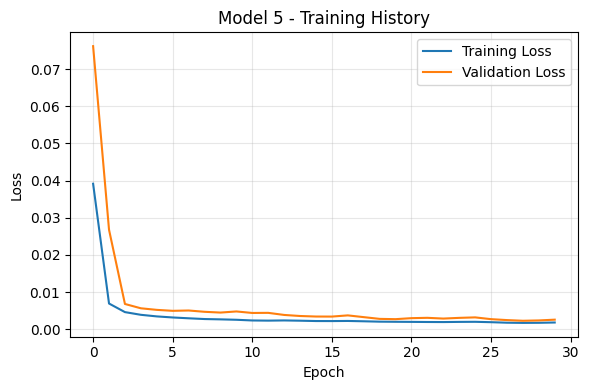

Model 5 Final Validation Loss: 0.002567
Model 5 Final Validation PSNR: 27.852917
Model 5 Final Validation SSIM: 0.971385
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


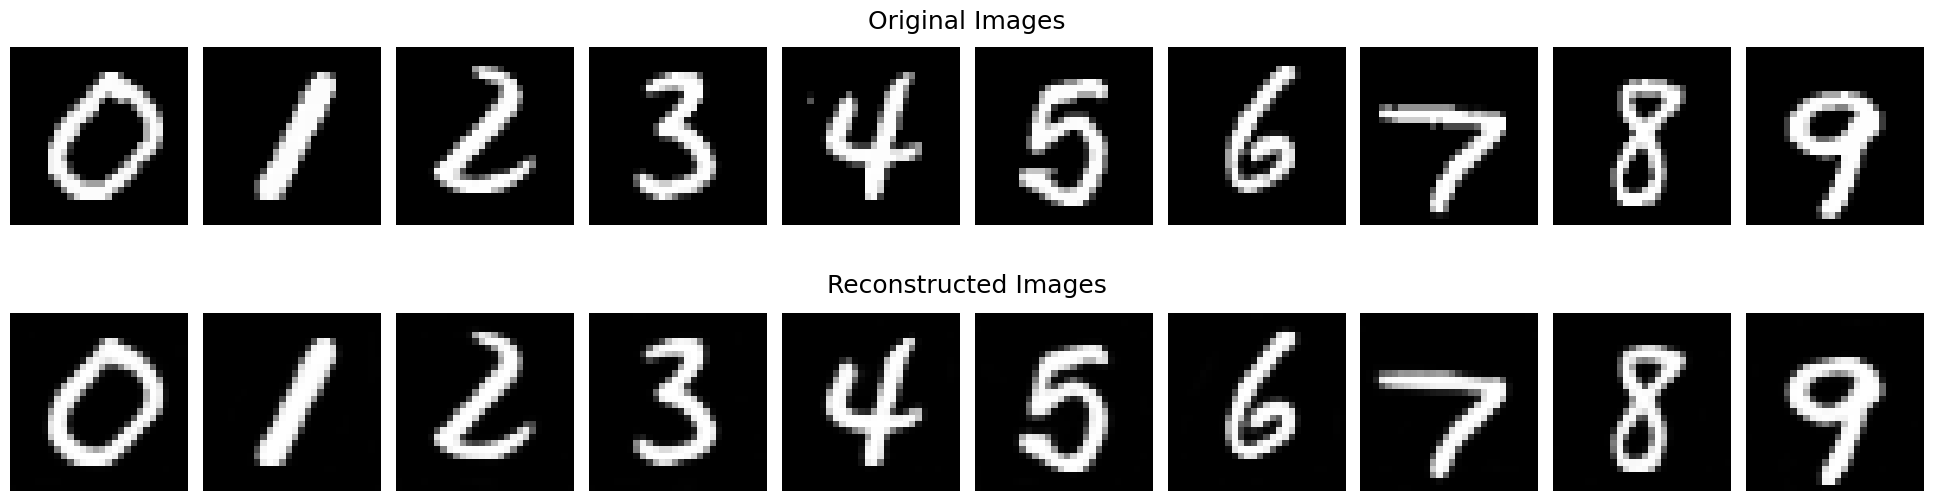

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step
Model 5 Test MSE: 0.002489


In [23]:
# Model 5: Convolutional Autoencoder
encoding_dim = 512

# Input needs to be reshaped to (28, 28, 1) for Conv2D
encoder_input = layers.Input(shape=(784,))
x = Reshape((28, 28, 1))(encoder_input)  

# Encoder: Conv2D + BatchNormalization + MaxPooling
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

# Flatten and create latent representation
x = Flatten()(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_5 = Model(encoder_input, latent, name='encoder_5')

# Decoder: Dense → Reshape
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(7 * 7 * 128, activation='relu')(decoder_input)
x = Reshape((7, 7, 128))(x)

# Decoder: Conv2D + BatchNormalization + UpSampling
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Flatten back to match input
decoder_output = Flatten()(x)

decoder_5 = Model(decoder_input, decoder_output, name='decoder_5')

# Autoencoder
autoencoder_5 = Model(encoder_input, decoder_5(encoder_5(encoder_input)), 
                      name='autoencoder_5_CNN')

# Compile with metrics
autoencoder_5.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=[dp.psnr, dp.ssim])

# Train
print("\nTraining Model 5 (Convolutional)...\n")
start_time = time.time()
history_5 = autoencoder_5.fit(x_train, x_train, epochs=30,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_5 = time.time() - start_time
print(f"\nModel 5 Training Time: {train_time_5:.2f} seconds")

# Plot training history
dp.plot_history(history_5, "Model 5")

# Store validation loss and metrics
val_loss_5 = history_5.history['val_loss'][-1]
val_psnr_5 = history_5.history['psnr'][-1]
val_ssim_5 = history_5.history['ssim'][-1]
print(f"Model 5 Final Validation Loss: {val_loss_5:.6f}")
print(f"Model 5 Final Validation PSNR: {val_psnr_5:.6f}")
print(f"Model 5 Final Validation SSIM: {val_ssim_5:.6f}")

# Visualize reconstructions on test set
reconstructed_5 = autoencoder_5.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_5, n=10)

# Calculate test MSE
mse_5 = dp.calculate_mse(x_test, autoencoder_5.predict(x_test))
print(f"Model 5 Test MSE: {mse_5:.6f}")


#### **Model 6: PCA Reconstruction**
Traditional PCA for comparison with autoencoders' performances.

Applying PCA Reconstruction: 784 -> 154 -> 784 dimensions
Explained variance: 95.02%
Compressed training shape: (60000, 154)
Compressed test shape: (10000, 154)
Reconstructed training shape: (60000, 784)
Reconstructed test shape: (10000, 784)

PCA Reconstruction Time: 3.36 seconds


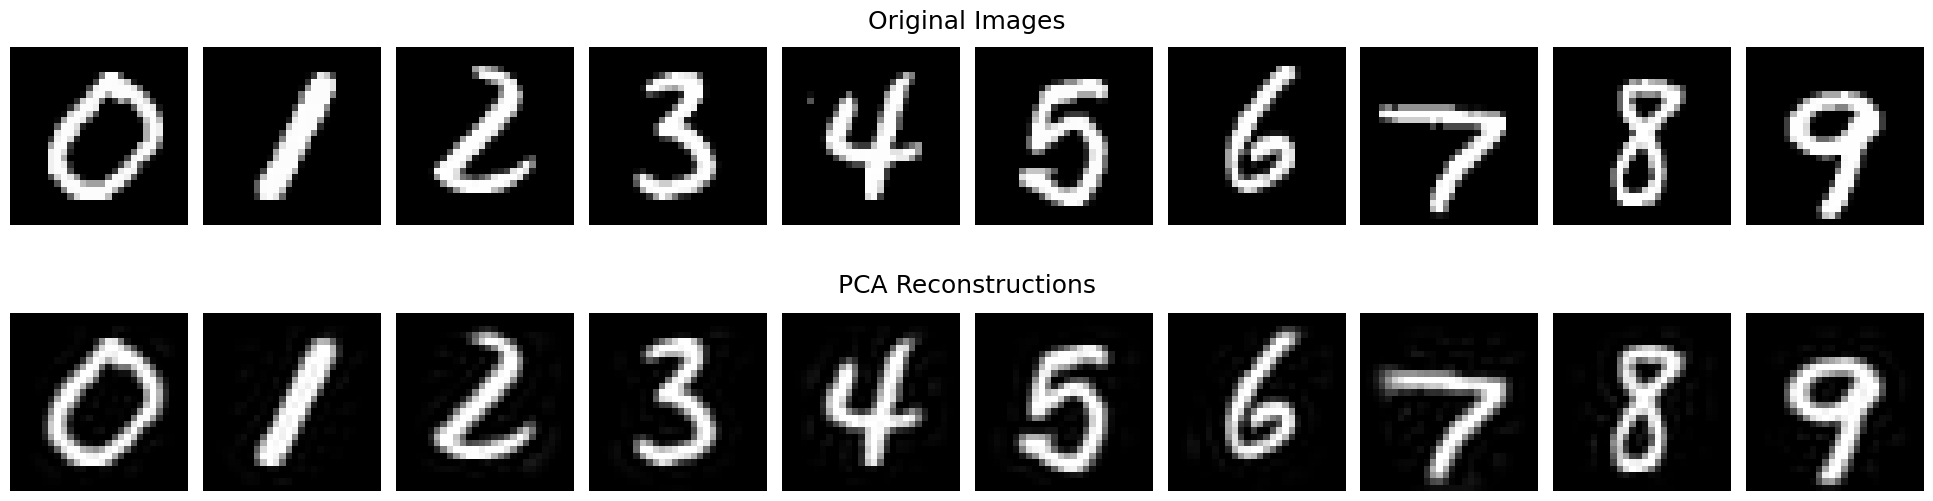


PCA Test MSE: 0.002632


In [24]:
# PCA Reconstruction
start_time = time.time()
x_train_pca, x_test_pca, n_components = dp.pca_reconstruction(x_train, x_test, n_components=0.95)
pca_time = time.time() - start_time
print(f"PCA Reconstruction Time: {pca_time:.2f} seconds")

# Visualize PCA reconstructions on test set
dp.plot_reconstructions(test_samples, x_test_pca[test_indices], n=10, title="PCA Reconstructions")

# Calculate PCA MSE
mse_pca = dp.calculate_mse(x_test, x_test_pca)
print(f"\nPCA Test MSE: {mse_pca:.6f}")

#### **Model Comparison Summary**
Compare all models and PCA.

MODEL COMPARISON
Model                               MSE          Encoding     Parameters      Training Time  
----------------------------------------------------------------------------------------------------
Model 1: Simple AE (32)             0.008717     32           209,968         46.25          
Model 2: Deep AE (64)               0.005673     64           1,149,520       140.75         
Model 3: Deep AE (128)              0.003439     128          1,132,944       135.11         
Model 4: Deep AE with Metrics       0.003265     128          1,132,944       202.36         
Model 5: Conv AE                    0.002489     512          6,763,905       2739.95        
Model 6: PCA                        0.002632     154          0               3.36           



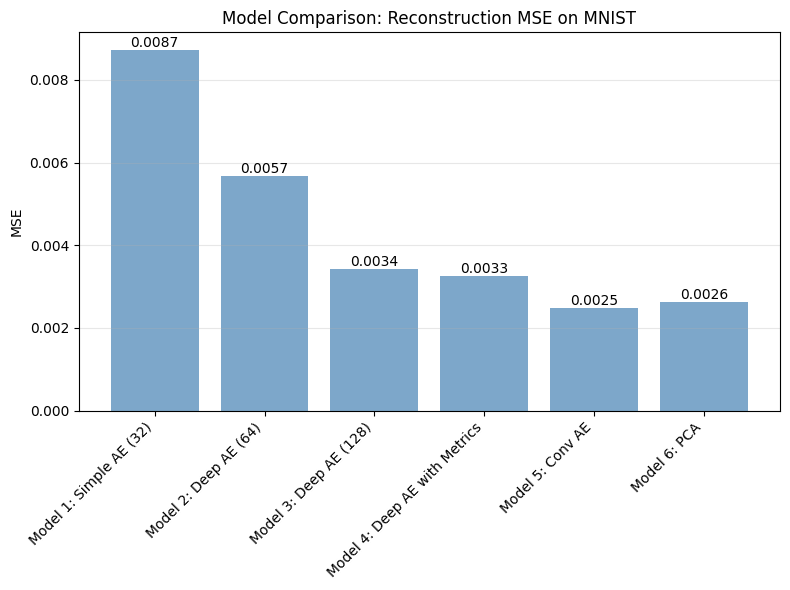

In [25]:
# Collect all results
results = [
    ("Model 1: Simple AE (32)", mse_1, 32, autoencoder_1.count_params(), train_time_1),
    ("Model 2: Deep AE (64)", mse_2, 64, autoencoder_2.count_params(), train_time_2),
    ("Model 3: Deep AE (128)", mse_3, 128, autoencoder_3.count_params(), train_time_3),
    ("Model 4: Deep AE with Metrics", mse_4, 128, autoencoder_4.count_params(), train_time_4),
    ("Model 5: Conv AE", mse_5, 512, autoencoder_5.count_params(), train_time_5),
    ("Model 6: PCA", mse_pca, 154, 0, pca_time)
]

# Print comparison table
dp.compare_models_table(results)

# Visualize MSE comparison
model_names = [r[0] for r in results]
mse_values = [r[1] for r in results]

plt.figure(figsize=(8, 6))
bars = plt.bar(range(len(model_names)), mse_values, color='steelblue', alpha=0.7)
plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.ylabel('MSE')
plt.title('Model Comparison: Reconstruction MSE on MNIST')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{mse_values[i]:.4f}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#### **CNN Classifier**
Compare classification accuracy between original and reconstructed test images.

In [27]:
# Create the CNN classifier
cnn_model = dp.build_digit_classifier()

# Get reconstructed test images from autoencoder_5
reconstructed_test = autoencoder_5.predict(x_test)

# Reshape for CNN input (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
reconstructed_test = reconstructed_test.reshape(-1, 28, 28, 1)

# Train the CNN on original training set
print("\nTraining CNN on original training set...\n")
cnn_history = cnn_model.fit(x_train, y_train, epochs=10,
            batch_size=128, validation_split=0.4, verbose=1)

# Evaluate on original test images
original_loss, original_accuracy = cnn_model.evaluate(x_test, y_test, verbose=0)

# Evaluate on reconstructed test images
reconstructed_loss, reconstructed_accuracy = cnn_model.evaluate(reconstructed_test, y_test, verbose=0)

print(f"\nTest Accuracy on Original Images: {original_accuracy:.4f}")
print(f"Test Accuracy on Reconstructed Images: {reconstructed_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step

Training CNN on original training set...

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8698 - loss: 0.4220 - val_accuracy: 0.9696 - val_loss: 0.0979
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9620 - loss: 0.1272 - val_accuracy: 0.9796 - val_loss: 0.0654
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9727 - loss: 0.0949 - val_accuracy: 0.9830 - val_loss: 0.0561
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9775 - loss: 0.0754 - val_accuracy: 0.9850 - val_loss: 0.0498
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9812 - loss: 0.0629 - val_accuracy: 0.9865 - val_loss: 0.0455
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9822 - loss: 0.0567 - val_accuracy: 0.9872 - val_loss: 0.0423
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9852 - loss: 0.0477 - val_accuracy: 0.9869 - val_loss: 0.0442
Epoch 8/10
2